# Cross-Attention Fusion Model — v2 (using your own train/test split)

**Beginner instructions:**

1. **Runtime → Change runtime type → T4 GPU**
2. Run cells in order (Shift+Enter). Upload `bindingdb_train_final.csv` and `bindingdb_test_final.csv` when prompted.
3. This dataset is large (~55,000 rows total) and proteins can be long (up to ~7,000 residues), so training will take longer than the earlier small-dataset version. **Run the "smoke test" cell (Step 8) first** to confirm everything works before committing to a full run — this avoids wasting hours on a run that errors out partway through.

**What changed from v1:**
- No more noisy IC50-pretraining stage — this dataset is confirmed Ki-based, so it's one clean training run.
- Protein sequences are truncated to 1024 tokens (this dataset spans far more target families than before, some proteins are huge) — a compute necessity, not a choice.
- Smaller batch size + gradient accumulation, since long protein sequences use more GPU memory.


## Step 1: Install packages

In [ ]:
!pip install -q rdkit transformers scikit-learn pandas numpy tqdm matplotlib
print("Done installing.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 19.5 MB/s eta 0:00:00
Done installing.


## Step 2: Imports and GPU check

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

RDLogger.DisableLog('rdApp.*')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type != "cuda":
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU, then re-run.")


Using device: cuda


## Step 3: Connect to Google Drive (one-time setup, then instant every time after)

**One-time setup (do this once, ever):**
1. Go to [drive.google.com](https://drive.google.com)
2. Create a folder, e.g. `bindingdb_project`
3. Upload `bindingdb_train_final.csv` and `bindingdb_test_final.csv` into that folder (this upload happens once, at your own pace — if it fails partway, just resume it, no Colab session is involved yet)

**Every session after that:** just run the cell below. It mounts your Drive (takes a few seconds) and reads the files directly from there — no re-upload, ever.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path to match wherever you put the folder in your Drive
DRIVE_FOLDER = '/content/drive/MyDrive/bindingdb_project'

import os
print("Files found in your Drive folder:")
print(os.listdir(DRIVE_FOLDER))


Mounted at /content/drive
Files found in your Drive folder:
[]


## Step 4: Load, clean, and deduplicate

- Strips leftover CXSMILES tags (e.g. `|r|`, `|r,c:3|`) from the SMILES column
- Averages pKi for exact duplicate (SMILES, Target) pairs, so the model doesn't see the same input with conflicting labels


In [ ]:
RAW_TRAIN_FILE = f"{DRIVE_FOLDER}/bindingdb_train_final.csv"
RAW_TEST_FILE = f"{DRIVE_FOLDER}/bindingdb_test_final.csv"

def clean_smiles(s):
    return str(s).split(' ')[0]

def is_valid_smiles(s):
    return Chem.MolFromSmiles(s) is not None

def load_and_clean(path):
    df = pd.read_csv(path)
    df = df.rename(columns={
        'Ligand SMILES': 'smiles',
        'BindingDB Target Chain Sequence 1': 'protein_seq',
        'Target Name': 'target_name'
    })
    df['smiles'] = df['smiles'].apply(clean_smiles)
    df = df[df['smiles'].apply(is_valid_smiles)].copy()
    # average pKi for exact duplicate (smiles, target) pairs
    agg_cols = {'pKi': 'mean', 'protein_seq': 'first'}
    other_cols = [c for c in df.columns if c not in ['smiles', 'target_name', 'pKi', 'protein_seq']]
    for c in other_cols:
        agg_cols[c] = 'first'
    df = df.groupby(['smiles', 'target_name'], as_index=False).agg(agg_cols)
    return df

df_train_full = load_and_clean(RAW_TRAIN_FILE)
df_test = load_and_clean(RAW_TEST_FILE)

print("Train rows after cleaning + dedup:", len(df_train_full))
print("Test rows after cleaning + dedup:", len(df_test))
print()
print("pKi range check - train:", df_train_full['pKi'].min(), "to", df_train_full['pKi'].max())
print("pKi range check - test: ", df_test['pKi'].min(), "to", df_test['pKi'].max())


Train rows after cleaning + dedup: 42772
Test rows after cleaning + dedup: 11233

pKi range check - train: 0.1550000000014108 to 12.0
pKi range check - test:  0.3151546383555875 to 11.844663962534938


## Step 5: Carve a validation set out of train

Your test file is already a clean, separate holdout (we confirmed zero SMILES overlap with train earlier) — so it stays untouched until final evaluation. We just need a validation split from *within* train, grouped by scaffold to avoid near-duplicate molecules leaking between train and validation.


In [ ]:
def get_scaffold(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except Exception:
        return smiles

df_train_full['scaffold'] = df_train_full['smiles'].apply(get_scaffold)

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx, val_idx = next(gss.split(df_train_full, groups=df_train_full['scaffold']))
df_train = df_train_full.iloc[train_idx].copy()
df_val = df_train_full.iloc[val_idx].copy()

print("Final train:", len(df_train))
print("Final val:  ", len(df_val))
print("Final test: ", len(df_test), "(untouched holdout)")


Final train: 38374
Final val:   4398
Final test:  11233 (untouched holdout)


## Step 6: Load pretrained tokenizers

Same choice as before: ChemBERTa for ligands, ESM-2 (small, 35M) for proteins — kept small to stay within Colab's free GPU memory.

**Sequence length note:** proteins in this dataset go up to 7,182 residues. We cap at 1024 tokens (covers ~90% of rows without truncation) purely because attention cost grows quadratically with length — padding to the true max would be too expensive to train on a free GPU.


In [ ]:
LIGAND_MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"
PROTEIN_MODEL_NAME = "facebook/esm2_t12_35M_UR50D"

ligand_tokenizer = AutoTokenizer.from_pretrained(LIGAND_MODEL_NAME)
protein_tokenizer = AutoTokenizer.from_pretrained(PROTEIN_MODEL_NAME)

MAX_LIGAND_LEN = 128
MAX_PROTEIN_LEN = 1024

print("Tokenizers loaded.")


config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/9.43k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.21k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizers loaded.


## Step 7: Dataset and model classes

In [ ]:
class AffinityDataset(Dataset):
    def __init__(self, df, ligand_tokenizer, protein_tokenizer):
        self.smiles = df['smiles'].tolist()
        self.proteins = df['protein_seq'].tolist()
        self.labels = df['pKi'].astype(float).tolist()
        self.ligand_tokenizer = ligand_tokenizer
        self.protein_tokenizer = protein_tokenizer

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        ligand_enc = self.ligand_tokenizer(
            self.smiles[idx], max_length=MAX_LIGAND_LEN, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        protein_enc = self.protein_tokenizer(
            self.proteins[idx], max_length=MAX_PROTEIN_LEN, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'ligand_input_ids': ligand_enc['input_ids'].squeeze(0),
            'ligand_attention_mask': ligand_enc['attention_mask'].squeeze(0),
            'protein_input_ids': protein_enc['input_ids'].squeeze(0),
            'protein_attention_mask': protein_enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.float)
        }


class CrossAttentionFusionModel(nn.Module):
    def __init__(self, ligand_model_name, protein_model_name,
                 fusion_dim=256, n_heads=4, dropout=0.3,
                 n_unfrozen_ligand_layers=2, n_unfrozen_protein_layers=2):
        super().__init__()

        self.ligand_encoder = AutoModel.from_pretrained(ligand_model_name)
        self.protein_encoder = AutoModel.from_pretrained(protein_model_name)

        # Freeze all, then selectively unfreeze the LAST few layers of each encoder.
        # (More unfrozen layers than v1 -- v1's train loss barely moved, a sign of underfitting,
        # so we give the model more room to adapt this time.)
        for p in self.ligand_encoder.parameters():
            p.requires_grad = False
        n_ligand_layers = len(self.ligand_encoder.encoder.layer)
        for i in range(n_ligand_layers - n_unfrozen_ligand_layers, n_ligand_layers):
            for p in self.ligand_encoder.encoder.layer[i].parameters():
                p.requires_grad = True

        for p in self.protein_encoder.parameters():
            p.requires_grad = False
        n_protein_layers = len(self.protein_encoder.encoder.layer)
        for i in range(n_protein_layers - n_unfrozen_protein_layers, n_protein_layers):
            for p in self.protein_encoder.encoder.layer[i].parameters():
                p.requires_grad = True

        ligand_hidden = self.ligand_encoder.config.hidden_size
        protein_hidden = self.protein_encoder.config.hidden_size

        self.ligand_proj = nn.Linear(ligand_hidden, fusion_dim)
        self.protein_proj = nn.Linear(protein_hidden, fusion_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim, num_heads=n_heads, dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(fusion_dim)
        self.dropout = nn.Dropout(dropout)

        self.regression_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, ligand_input_ids, ligand_attention_mask,
                protein_input_ids, protein_attention_mask):

        ligand_out = self.ligand_encoder(
            input_ids=ligand_input_ids, attention_mask=ligand_attention_mask
        ).last_hidden_state

        protein_out = self.protein_encoder(
            input_ids=protein_input_ids, attention_mask=protein_attention_mask
        ).last_hidden_state

        ligand_feat = self.ligand_proj(ligand_out)
        protein_feat = self.protein_proj(protein_out)

        protein_key_padding_mask = (protein_attention_mask == 0)

        fused, _ = self.cross_attn(
            query=ligand_feat, key=protein_feat, value=protein_feat,
            key_padding_mask=protein_key_padding_mask
        )
        fused = self.norm(fused + ligand_feat)
        fused = self.dropout(fused)

        mask = ligand_attention_mask.unsqueeze(-1).float()
        pooled = (fused * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)

        pred = self.regression_head(pooled).squeeze(-1)
        return pred


## Step 7b: Pre-tokenize and cache the dataset (do this once — makes every epoch much faster)

Right now the tokenizer would otherwise re-run on every row, every epoch. Instead, we tokenize everything **once**, save the result as tensors to Drive, and every training run (this session or a future one after a disconnect) just loads the cached tensors instantly.

This cell will take a few minutes the first time (progress bar shown). Every time after, it loads in seconds.


In [ ]:
import os
from tqdm.auto import tqdm

def build_or_load_cache(df, split_name, ligand_tokenizer, protein_tokenizer):
    cache_path = f"{DRIVE_FOLDER}/cache_{split_name}.pt"

    if os.path.exists(cache_path):
        print(f"Loading cached tokenized tensors for '{split_name}' from Drive...")
        return torch.load(cache_path)

    print(f"No cache found for '{split_name}' -- tokenizing {len(df)} rows now (one-time cost)...")
    ligand_ids, ligand_mask = [], []
    protein_ids, protein_mask = [], []
    labels = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Tokenizing {split_name}"):
        l_enc = ligand_tokenizer(row['smiles'], max_length=MAX_LIGAND_LEN, padding='max_length',
                                  truncation=True, return_tensors='pt')
        p_enc = protein_tokenizer(row['protein_seq'], max_length=MAX_PROTEIN_LEN, padding='max_length',
                                   truncation=True, return_tensors='pt')
        ligand_ids.append(l_enc['input_ids'].squeeze(0))
        ligand_mask.append(l_enc['attention_mask'].squeeze(0))
        protein_ids.append(p_enc['input_ids'].squeeze(0))
        protein_mask.append(p_enc['attention_mask'].squeeze(0))
        labels.append(float(row['pKi']))

    cache = {
        'ligand_input_ids': torch.stack(ligand_ids),
        'ligand_attention_mask': torch.stack(ligand_mask),
        'protein_input_ids': torch.stack(protein_ids),
        'protein_attention_mask': torch.stack(protein_mask),
        'labels': torch.tensor(labels, dtype=torch.float)
    }
    torch.save(cache, cache_path)
    print(f"Cached '{split_name}' tensors saved to Drive.")
    return cache


class PrecomputedAffinityDataset(Dataset):
    """Reads from pre-tokenized tensors instead of calling the tokenizer every time."""
    def __init__(self, cache_dict):
        self.cache = cache_dict

    def __len__(self):
        return len(self.cache['labels'])

    def __getitem__(self, idx):
        return {
            'ligand_input_ids': self.cache['ligand_input_ids'][idx],
            'ligand_attention_mask': self.cache['ligand_attention_mask'][idx],
            'protein_input_ids': self.cache['protein_input_ids'][idx],
            'protein_attention_mask': self.cache['protein_attention_mask'][idx],
            'label': self.cache['labels'][idx]
        }


train_cache = build_or_load_cache(df_train, 'train', ligand_tokenizer, protein_tokenizer)
val_cache = build_or_load_cache(df_val, 'val', ligand_tokenizer, protein_tokenizer)
test_cache = build_or_load_cache(df_test, 'test', ligand_tokenizer, protein_tokenizer)

print("All splits tokenized and cached.")


No cache found for 'train' -- tokenizing 38374 rows now (one-time cost)...


Tokenizing train:   0%|          | 0/38374 [00:00<?, ?it/s]

Cached 'train' tensors saved to Drive.
No cache found for 'val' -- tokenizing 4398 rows now (one-time cost)...


Tokenizing val:   0%|          | 0/4398 [00:00<?, ?it/s]

Cached 'val' tensors saved to Drive.
No cache found for 'test' -- tokenizing 11233 rows now (one-time cost)...


Tokenizing test:   0%|          | 0/11233 [00:00<?, ?it/s]

Cached 'test' tensors saved to Drive.
All splits tokenized and cached.


## Step 8: Smoke test — run this BEFORE the full training run

This trains on a tiny 200-row slice for 1 epoch, just to confirm the whole pipeline runs without errors (shapes, memory, tokenization). Takes a minute or two. **Don't skip this** — catching a bug here saves you from discovering it 2 hours into a full run.

In [ ]:
smoke_df = df_train.sample(n=min(200, len(df_train)), random_state=0)
smoke_dataset = AffinityDataset(smoke_df, ligand_tokenizer, protein_tokenizer)
smoke_loader = DataLoader(smoke_dataset, batch_size=4, shuffle=True)

smoke_model = CrossAttentionFusionModel(LIGAND_MODEL_NAME, PROTEIN_MODEL_NAME).to(device)
smoke_optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, smoke_model.parameters()), lr=1e-4)
smoke_criterion = nn.MSELoss()

smoke_model.train()
for batch in smoke_loader:
    smoke_optimizer.zero_grad()
    preds = smoke_model(
        batch['ligand_input_ids'].to(device),
        batch['ligand_attention_mask'].to(device),
        batch['protein_input_ids'].to(device),
        batch['protein_attention_mask'].to(device),
    )
    loss = smoke_criterion(preds, batch['label'].to(device))
    loss.backward()
    smoke_optimizer.step()

print("Smoke test passed. Loss on last batch:", loss.item())
del smoke_model, smoke_optimizer, smoke_loader, smoke_dataset
torch.cuda.empty_cache()


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  179MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  179MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  136MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Smoke test passed. Loss on last batch: 9.886260986328125


## Step 9: Training and evaluation functions (with gradient accumulation)

In [ ]:
from tqdm.auto import tqdm
import time

scaler = torch.cuda.amp.GradScaler()

def train_epoch(model, loader, optimizer, criterion, device, accum_steps=4):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()
    n_batches = len(loader)
    pbar = tqdm(enumerate(loader), total=n_batches, desc="Training", leave=True)
    start_time = time.time()

    for i, batch in pbar:
        with torch.cuda.amp.autocast():  # mixed precision -- ~1.5-2x faster on T4, less memory
            preds = model(
                batch['ligand_input_ids'].to(device),
                batch['ligand_attention_mask'].to(device),
                batch['protein_input_ids'].to(device),
                batch['protein_attention_mask'].to(device),
            )
            labels = batch['label'].to(device)
            loss = criterion(preds, labels) / accum_steps

        scaler.scale(loss).backward()

        if (i + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps * len(labels)

        if (i + 1) % 10 == 0 or (i + 1) == n_batches:
            elapsed = time.time() - start_time
            batches_per_sec = (i + 1) / elapsed
            eta_min = (n_batches - i - 1) / batches_per_sec / 60 if batches_per_sec > 0 else float('inf')
            pbar.set_postfix({
                'avg_loss': f"{total_loss / ((i+1) * loader.batch_size):.4f}",
                'batches/s': f"{batches_per_sec:.2f}",
                'ETA_min': f"{eta_min:.1f}"
            })

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="Evaluating", leave=False):
        with torch.cuda.amp.autocast():
            preds = model(
                batch['ligand_input_ids'].to(device),
                batch['ligand_attention_mask'].to(device),
                batch['protein_input_ids'].to(device),
                batch['protein_attention_mask'].to(device),
            )
            labels = batch['label'].to(device)
            loss = criterion(preds, labels)
        total_loss += loss.item() * len(labels)
        all_preds.extend(preds.float().cpu().numpy().tolist())
        all_labels.extend(labels.float().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    rmse = np.sqrt(np.mean((all_preds - all_labels) ** 2))
    mae = np.mean(np.abs(all_preds - all_labels))
    ss_res = np.sum((all_labels - all_preds) ** 2)
    ss_tot = np.sum((all_labels - np.mean(all_labels)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    pearson_r, _ = pearsonr(all_preds, all_labels) if len(all_preds) > 1 else (float('nan'), None)

    return {'loss': avg_loss, 'rmse': rmse, 'mae': mae, 'r2': r2, 'pearson_r': pearson_r}, all_preds, all_labels


/tmp/ipykernel_606/4083849090.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## Step 10: Full training run

**Note on runtime:** with ~40,000 training rows and protein sequences up to 1024 tokens, each epoch will take considerably longer than the earlier small-dataset version — potentially 30-90+ minutes per epoch depending on Colab's assigned GPU. Consider starting with `MAX_EPOCHS = 3` to see how long one epoch actually takes before committing to more.


In [ ]:
import json
import os

BATCH_SIZE = 8     # doubled -- mixed precision frees up enough memory for this
ACCUM_STEPS = 2    # effective batch size still 16
MAX_EPOCHS = 8     # increased since epoch 1 showed real learning (val R2 0.33) -- worth letting it run longer
LEARNING_RATE = 1e-4
PATIENCE = 3

train_dataset = PrecomputedAffinityDataset(train_cache)
val_dataset = PrecomputedAffinityDataset(val_cache)
test_dataset = PrecomputedAffinityDataset(test_cache)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model = CrossAttentionFusionModel(LIGAND_MODEL_NAME, PROTEIN_MODEL_NAME).to(device)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
criterion = nn.MSELoss()

# --- RESUME LOGIC: automatically picks up where a dropped connection left off ---
CHECKPOINT_PATH = f"{DRIVE_FOLDER}/best_model_v2.pt"
META_PATH = f"{DRIVE_FOLDER}/training_meta.json"

start_epoch = 1
best_val_loss = float('inf')
epochs_no_improve = 0

if os.path.exists(CHECKPOINT_PATH) and os.path.exists(META_PATH):
    print("Found existing checkpoint in Drive -- resuming instead of starting over.")
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    with open(META_PATH, 'r') as f:
        meta = json.load(f)
    start_epoch = meta['last_epoch'] + 1
    best_val_loss = meta['best_val_loss']
    print(f"Resuming from epoch {start_epoch}, best val loss so far: {best_val_loss:.4f}")
else:
    print("No existing checkpoint found -- starting fresh.")

print(f"Training on {len(df_train)} rows, validating on {len(df_val)} rows...")
for epoch in range(start_epoch, MAX_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, accum_steps=ACCUM_STEPS)
    val_metrics, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_metrics['loss'])

    print(f"Epoch {epoch}/{MAX_EPOCHS} - train loss: {train_loss:.4f} | "
          f"val loss: {val_metrics['loss']:.4f} | val RMSE: {val_metrics['rmse']:.4f} | "
          f"val R2: {val_metrics['r2']:.4f}")

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model_v2.pt")
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        with open(META_PATH, 'w') as f:
            json.dump({'last_epoch': epoch, 'best_val_loss': best_val_loss}, f)
        print("  -> New best model saved (locally and to Drive).")
    else:
        epochs_no_improve += 1
        # still update last_epoch in meta so a resume doesn't repeat this epoch, even without improvement
        with open(META_PATH, 'w') as f:
            json.dump({'last_epoch': epoch, 'best_val_loss': best_val_loss}, f)
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping after {epoch} epochs.")
            break

print("Training complete (or paused -- rerun this cell any time to resume automatically).")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


No existing checkpoint found -- starting fresh.
Training on 38374 rows, validating on 4398 rows...


...

Evaluating:   0%|          | 0/550 [00:00<?, ?it/s]

Epoch 7/8 - train loss: 1.1730 | val loss: 1.5073 | val RMSE: 1.2277 | val R2: 0.4249
  -> New best model saved (locally and to Drive).


Training:   0%|          | 0/4797 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/550 [00:00<?, ?it/s]

Epoch 8/8 - train loss: 1.1212 | val loss: 1.8743 | val RMSE: 1.3690 | val R2: 0.2849
Training complete (or paused -- rerun this cell any time to resume automatically).


## Step 11: Final evaluation on the held-out test set

Evaluating:   0%|          | 0/1405 [00:00<?, ?it/s]

/tmp/ipykernel_606/4083849090.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


=== Final Test Set Performance ===
RMSE:      1.2594
MAE:       0.9760
R2:        0.4726
Pearson r: 0.7056


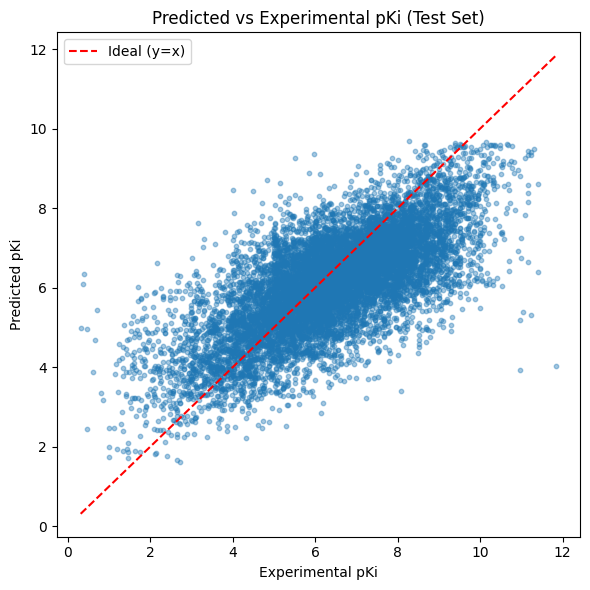

In [ ]:
model.load_state_dict(torch.load("best_model_v2.pt"))
test_metrics, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print("=== Final Test Set Performance ===")
print(f"RMSE:      {test_metrics['rmse']:.4f}")
print(f"MAE:       {test_metrics['mae']:.4f}")
print(f"R2:        {test_metrics['r2']:.4f}")
print(f"Pearson r: {test_metrics['pearson_r']:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(test_labels, test_preds, alpha=0.4, s=10)
min_val = min(test_labels.min(), test_preds.min())
max_val = max(test_labels.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y=x)')
plt.xlabel("Experimental pKi")
plt.ylabel("Predicted pKi")
plt.title("Predicted vs Experimental pKi (Test Set)")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_actual_v2.png", dpi=150)
plt.show()


## Step 12: Save your results

In [ ]:
from google.colab import files as colab_files

results_df = pd.DataFrame({
    'smiles': df_test['smiles'].tolist(),
    'target_name': df_test['target_name'].tolist(),
    'actual_pKi': test_labels,
    'predicted_pKi': test_preds
})
results_df.to_csv('test_set_predictions_v2.csv', index=False)
results_df.to_csv(f'{DRIVE_FOLDER}/test_set_predictions_v2.csv', index=False)  # backup to Drive

colab_files.download('best_model_v2.pt')
colab_files.download('test_set_predictions_v2.csv')
colab_files.download('predicted_vs_actual_v2.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>